Generating dataset...

--- Exploratory Data Analysis ---
Dataset Size: 2739 unique X-turn states.
X wins: 1830 (66.81%)
Draws: 441 (16.10%)


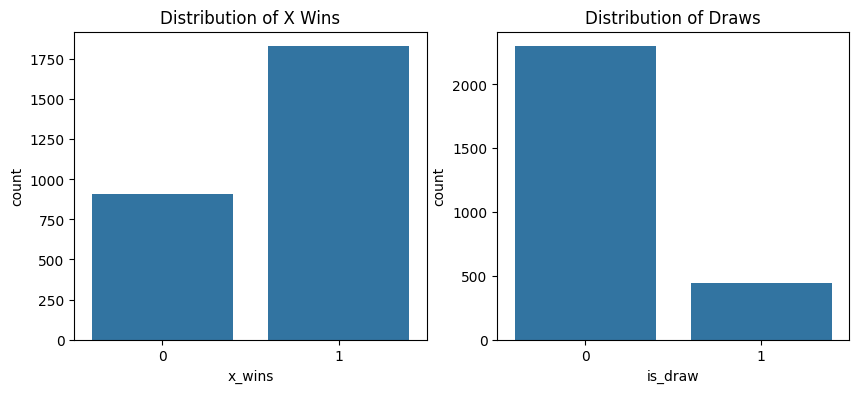


--- Logistic Regression Results (X Wins) ---
              precision    recall  f1-score   support

           0       0.60      0.35      0.44       199
           1       0.70      0.87      0.77       349

    accuracy                           0.68       548
   macro avg       0.65      0.61      0.61       548
weighted avg       0.66      0.68      0.65       548



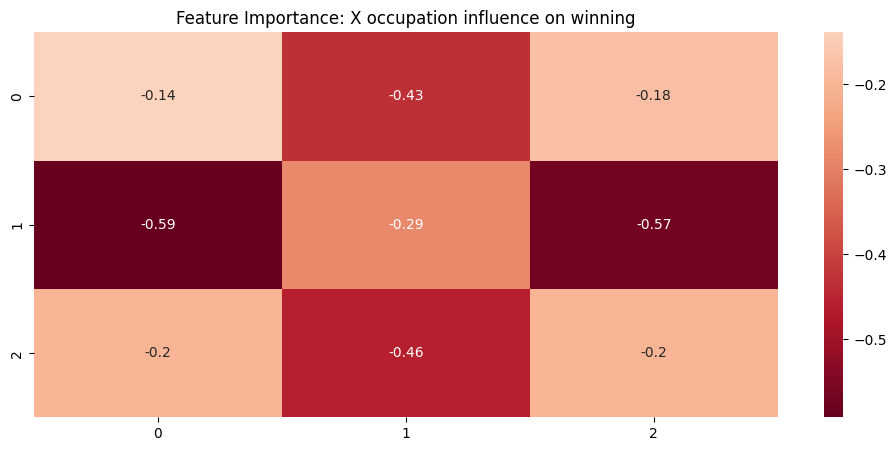


--- Random Forest Results (X Wins) ---
RF Accuracy: 0.8613
Fichiers .pkl générés


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# --- STEP 0: GENERATOR MINIMAX-ALPHABETA ---

def check_winner(board):
    win_indices = [
        (0, 1, 2), (3, 4, 5), (6, 7, 8), # Rows
        (0, 3, 6), (1, 4, 7), (2, 5, 8), # Cols
        (0, 4, 8), (2, 4, 6)             # Diags
    ]
    for r in win_indices:
        if board[r[0]] == board[r[1]] == board[r[2]] != 0:
            return board[r[0]]
    if 0 not in board:
        return 0 # Draw
    return None # Ongoing

def minimax(board, depth, is_maximizing, alpha, beta):
    res = check_winner(board)
    if res == 1: return 10 - depth  # X wins
    if res == -1: return depth - 10 # O wins
    if res == 0: return 0           # Draw

    if is_maximizing:
        best_score = -float('inf')
        for i in range(9):
            if board[i] == 0:
                board[i] = 1
                score = minimax(board, depth + 1, False, alpha, beta)
                board[i] = 0
                best_score = max(score, best_score)
                alpha = max(alpha, score)
                if beta <= alpha: break
        return best_score
    else:
        best_score = float('inf')
        for i in range(9):
            if board[i] == 0:
                board[i] = -1
                score = minimax(board, depth + 1, True, alpha, beta)
                board[i] = 0
                best_score = min(score, best_score)
                beta = min(beta, score)
                if beta <= alpha: break
        return best_score

def generate_dataset():
    """Generates all valid board states where it's X's turn."""
    dataset = []

    def backtrack(board, turn):
        # We only save states where it is X's turn to move
        if turn == 1:
            res = minimax(board, 0, True, -float('inf'), float('inf'))
            row = []
            for cell in board:
                row.extend([1 if cell == 1 else 0, 1 if cell == -1 else 0])

            # Labeling
            x_wins = 1 if res > 0 else 0
            is_draw = 1 if res == 0 else 0
            row.extend([x_wins, is_draw])
            dataset.append(row)

        # Explore next moves
        winner = check_winner(board)
        if winner is not None: return

        for i in range(9):
            if board[i] == 0:
                board[i] = turn
                backtrack(board, -turn)
                board[i] = 0

    backtrack([0]*9, 1)

    cols = []
    for i in range(9):
        cols.extend([f'c{i}_x', f'c{i}_o'])
    cols.extend(['x_wins', 'is_draw'])

    df = pd.DataFrame(dataset, columns=cols).drop_duplicates()
    df.to_csv('dataset.csv', index=False)
    return df

print("Generating dataset...")
df = generate_dataset()

# --- STEP 1: EDA ---
print("\n--- Exploratory Data Analysis ---")
print(f"Dataset Size: {len(df)} unique X-turn states.")
print(f"X wins: {df['x_wins'].sum()} ({df['x_wins'].mean():.2%})")
print(f"Draws: {df['is_draw'].sum()} ({df['is_draw'].mean():.2%})")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='x_wins', data=df)
plt.title("Distribution of X Wins")
plt.subplot(1, 2, 2)
sns.countplot(x='is_draw', data=df)
plt.title("Distribution of Draws")
plt.show()

# --- STEP 2: BASELINE (LOGISTIC REGRESSION) ---
X = df.drop(['x_wins', 'is_draw'], axis=1)
y_win = df['x_wins']
y_draw = df['is_draw']

X_train, X_test, y_win_train, y_win_test = train_test_split(X, y_win, test_size=0.2)
_, _, y_draw_train, y_draw_test = train_test_split(X, y_draw, test_size=0.2)

lr_win = LogisticRegression().fit(X_train, y_win_train)
lr_draw = LogisticRegression().fit(X_train, y_draw_train)

print("\n--- Logistic Regression Results (X Wins) ---")
print(classification_report(y_win_test, lr_win.predict(X_test)))

# Visualization of Coefficients
coefs = lr_win.coef_[0].reshape(9, 2)
plt.figure(figsize=(12, 5))
sns.heatmap(coefs[:, 0].reshape(3,3), annot=True, cmap='RdBu', center=0)
plt.title("Feature Importance: X occupation influence on winning")
plt.show()

# --- STEP 3: ADVANCED MODELS (RANDOM FOREST) ---
rf_win = RandomForestClassifier(n_estimators=100).fit(X_train, y_win_train)
print("\n--- Random Forest Results (X Wins) ---")
print(f"RF Accuracy: {accuracy_score(y_win_test, rf_win.predict(X_test)):.4f}")
# Créer le dossier physiquement sur ton PC
if not os.path.exists('models'):
    os.makedirs('models')
#Sauvegarder des modèles
try:
    with open('models/model_x_wins.pkl', 'wb') as f:
        pickle.dump(lr_win, f)
    with open('models/model_is_draw.pkl', 'wb') as f:
        pickle.dump(lr_draw, f)
    print("Fichiers .pkl générés")
except NameError:
    print("Erreur : Les variables lr_win ou lr_draw n'ont pas été définies plus haut.")